Multiple machine learning models are combined together to make predictions.

Improve accuracy, better predictions, gives more reliable results than a single model.

### Types

Bagging(Bootstrap Aggregation)

Boosting

Both can be used for classification and regression.

### Basic idea of Bagging

Multiple models are trained.

Each model receives a different sample of the dataset.

All models work independently.

Their outputs are combined to produce the final prediction.

### Components of Bagging

Dataset

Base Learners (Multiple models used by bagging)

### Training Process

Step 1 : Create dataset samples. (Different sample taken from training dataset, Each sample given to different model).

Step 2 : Train Models

Step 3 : Make Predictions (Each model predicts separately).

Final Prediction in Classification (Majority Voting Classifier)

Final Prediction in Regression (Average of all Outputs)

In [23]:
# Important characteristic of Bagging (Parallel Training --> All models are trained at the same time)

### Boosting (Main Idea)

Multiple weak learners are combined.

Models are connected sequentially.

Each models tries to improve the mistakes made by previous model.

Together they form a strong learner.

### Training Process

Step 1 : Give the entire dataset to Model 1. (Model 1 trains and makes predictions.)

Step 2 : Model 1 makes some mistakes.

Step 3 : Those incorrectly predicted recoreds are passed to Model 2 along with some additional records which are correct.

Step 4 : Model 2 learns from those mistakes. It also makes some errors. Those erros are passed to Model 3.

Step 5 : The process continues (M1 -> M2 -> M3 -> ..... -> Mn)

Each new model focuses on correcting previous mistakes.

In [24]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

In [25]:
# Loading data
df = pd.read_csv('cardekho.csv')
# print(f'Rows : {df.shape[0]}')
# print(f'Columns : {df.shape[1]}')

In [26]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [27]:
df.tail()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
15410,19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


In [28]:
df.shape

(15411, 14)

In [29]:
print('Column data types:')
print(df.dtypes)

Column data types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object


In [30]:
df.sample()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
10969,13944,Rolls-Royce Ghost,Rolls-Royce,Ghost,4,5000,Individual,Petrol,Automatic,10.2,6592,563.0,4,24200000


In [31]:
df.drop(columns=['Unnamed: 0', 'car_name', 'model'], inplace= True)
print('Dropped Unnecessary columns.')

Dropped Unnecessary columns.


In [32]:
df.sample()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9539,Maruti,3,20002,Trustmark Dealer,Petrol,Manual,22.0,1197,81.8,5,575000


In [33]:
print('Missing values per columns: ')
df.isna().sum()

Missing values per columns: 


brand                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [34]:
before = len(df)
df.dropna(inplace=True)
after = len(df)
print(f'Removed {before - after}  rows containing missing values.')
print(f'Dataset now has {after} rows')

Removed 0  rows containing missing values.
Dataset now has 15411 rows


In [37]:
df.duplicated().sum()

np.int64(168)

In [38]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Removed {before - after} duplicate rows.')
print(f'Dataset now has {after} rows.')

Removed 168 duplicate rows.
Dataset now has 15243 rows.


In [39]:
Q1 = df['selling_price'].quantile(0.01)
Q3 = df['selling_price'].quantile(0.99)
before = len(df)

df = df[(df['selling_price'] >= Q1) & (df['selling_price'] <= Q3)]
after = len(df)

print(f'Removed {before - after} extreme outlier rows in selling price.')
print(f'Final dataset size: {after} rows.')

Removed 286 extreme outlier rows in selling price.
Final dataset size: 14957 rows.


In [40]:
# EDA
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,14957.000000,1.495700e+04,14957.000000,14957.000000,14957.000000,14957.000000,1.495700e+04
mean,5.984155,5.577294e+04,19.758068,1476.845691,99.293523,5.331016,7.218893e+05
std,2.897593,5.200433e+04,4.155403,497.563595,38.950998,0.808162,5.925512e+05
min,0.000000,1.000000e+02,7.500000,793.000000,38.400000,0.000000,1.200000e+05
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.700000,1248.000000,88.500000,5.000000,5.550000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.000000e+05
max,25.000000,3.800000e+06,33.540000,5461.000000,500.000000,9.000000,4.500000e+06


In [41]:
pd.set_option('display.float_format', lambda x: '%.2f'% x)

In [42]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,14957.00,14957.00,14957.00,14957.00,14957.00,14957.00,14957.00
mean,5.98,55772.94,19.76,1476.85,99.29,5.33,721889.28
std,2.90,52004.33,4.16,497.56,38.95,0.81,592551.23
min,0.00,100.00,7.50,793.00,38.40,0.00,120000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.70,1248.00,88.50,5.00,555000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,800000.00
max,25.00,3800000.00,33.54,5461.00,500.00,9.00,4500000.00


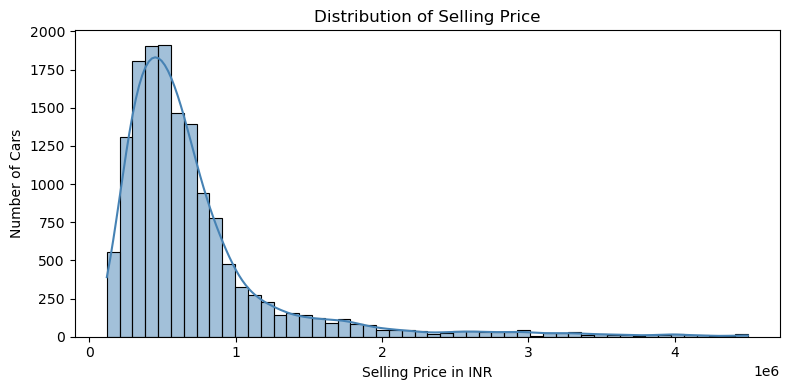

In [44]:
plt.figure(figsize=(8,4))
sns.histplot(df['selling_price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price in INR')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.savefig('plot1_selling_price_distribution.png')
plt.show()

In [45]:
df.sample()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9423,Datsun,5,36000,Dealer,Petrol,Manual,22.70,799,53.64,5,235000


In [46]:
avg_price = df.groupby('fuel_type')['selling_price'].mean().sort_values(ascending=False)
avg_price

fuel_type
Electric   1853500.00
Diesel      923810.07
Petrol      538550.83
CNG         417688.96
LPG         223605.26
Name: selling_price, dtype: float64

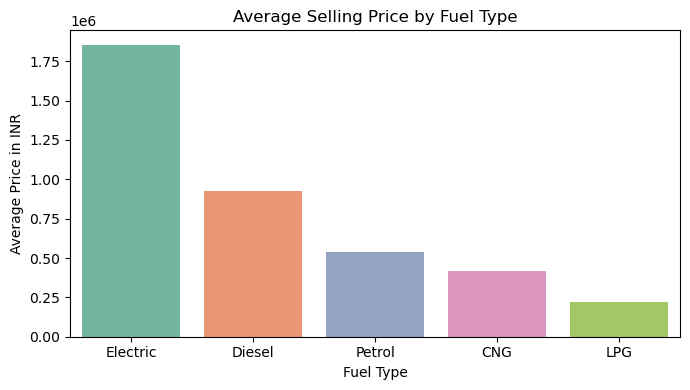

In [47]:
plt.figure(figsize=(7,4))
avg_price = df.groupby('fuel_type')['selling_price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values,palette='Set2')
plt.title("Average Selling Price by Fuel Type")
plt.xlabel('Fuel Type')
plt.ylabel('Average Price in INR')
plt.tight_layout()
plt.savefig('plot2_price_by_fuel.png')
plt.show()

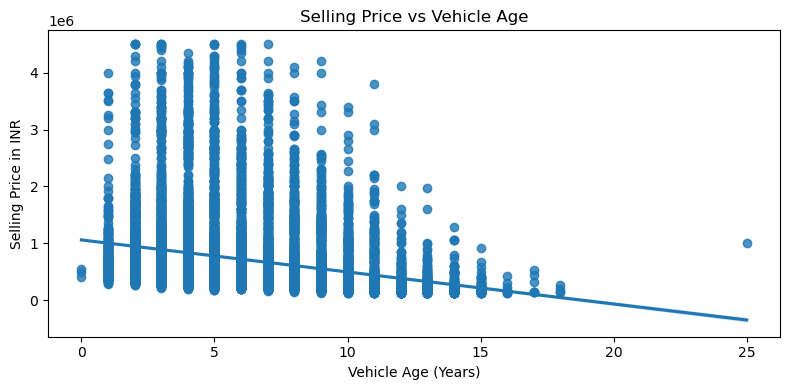

In [48]:
plt.figure(figsize=(8,4))
sns.regplot(x='vehicle_age', y='selling_price', data=df)
plt.title('Selling Price vs Vehicle Age')
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Selling Price in INR')
plt.tight_layout()
plt.savefig('plot3_price_by_age.png')
plt.show()

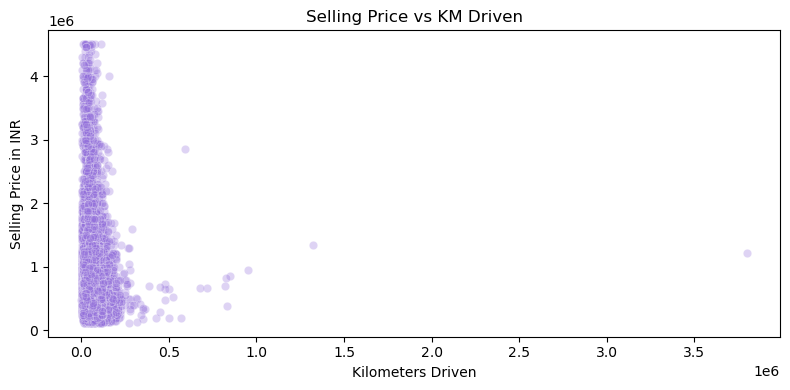

In [49]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='km_driven', y='selling_price', data=df, alpha=0.3, color='mediumpurple')
plt.title('Selling Price vs KM Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price in INR')
plt.tight_layout()
plt.savefig('plot4_price_by_km.png')
plt.show()

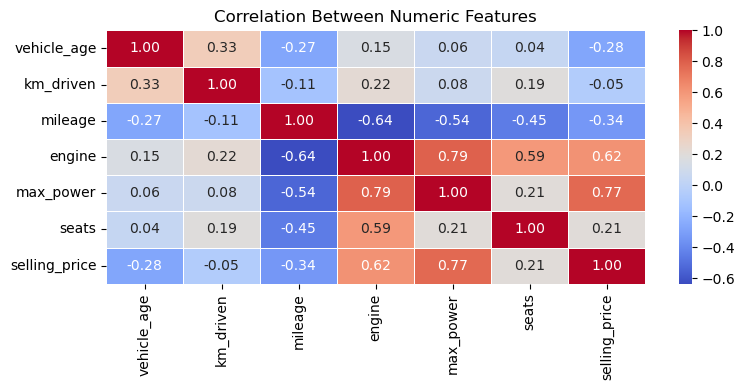

In [50]:
plt.figure(figsize=(8, 4))
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.savefig('plot5_correlation.png')
plt.show()

In [51]:
# Feature Engineering

In [52]:
df.sample()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
844,Hyundai,1,15000,Individual,Petrol,Automatic,20.70,1197,81.86,5,650000


In [53]:
cat_cols = ['brand','seller_type','fuel_type','transmission_type']
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f'Encoded {col} column')

Encoded brand column
Encoded seller_type column
Encoded fuel_type column
Encoded transmission_type column


In [54]:
df.sample()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
8701,17,9,186900,0,1,0,11.30,2987,254.80,7,1690000


In [55]:
df['km_driven'].unique()

array([ 120000,   20000,   60000, ...,    9229,   10723, 3800000],
      shape=(3647,))

In [56]:
df['price_per_km'] = df['selling_price'] / df['km_driven']
df.head()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,price_per_km
0,16,9,120000,1,4,1,19.70,796,46.30,5,120000,1.00
1,6,5,20000,1,4,1,18.90,1197,82.00,5,550000,27.50
2,6,11,60000,1,4,1,17.00,1197,80.00,5,215000,3.58
3,16,9,37000,1,4,1,20.92,998,67.10,5,226000,6.11
4,4,6,30000,0,1,1,22.77,1498,98.59,5,570000,19.00


In [57]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

In [58]:
X

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,price_per_km
0,16,9,120000,1,4,1,19.70,796,46.30,5,1.00
1,6,5,20000,1,4,1,18.90,1197,82.00,5,27.50
2,6,11,60000,1,4,1,17.00,1197,80.00,5,3.58
3,16,9,37000,1,4,1,20.92,998,67.10,5,6.11
4,4,6,30000,0,1,1,22.77,1498,98.59,5,19.00
...,...,...,...,...,...,...,...,...,...,...,...
15406,6,9,10723,0,4,1,19.81,1086,68.05,5,23.31
15407,16,2,18000,0,4,1,17.50,1373,91.10,7,51.39
15408,22,6,67000,0,1,1,21.14,1498,103.52,5,6.34
15409,15,5,3800000,0,1,1,16.00,2179,140.00,7,0.32


In [59]:
y

0         120000
1         550000
2         215000
3         226000
4         570000
          ...   
15406     250000
15407     925000
15408     425000
15409    1225000
15410    1200000
Name: selling_price, Length: 14957, dtype: int64

In [60]:
X = X.drop(columns=['price_per_km'])
X.head()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,16,9,120000,1,4,1,19.70,796,46.30,5
1,6,5,20000,1,4,1,18.90,1197,82.00,5
2,6,11,60000,1,4,1,17.00,1197,80.00,5
3,16,9,37000,1,4,1,20.92,998,67.10,5
4,4,6,30000,0,1,1,22.77,1498,98.59,5


In [62]:
print(f'X shape (features) : {X.shape}')
print(f'y shape (target): {y.shape}')

print(f'\n Feature columns used: \n {list(X.columns)}')

X shape (features) : (14957, 10)
y shape (target): (14957,)

 Feature columns used: 
 ['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']


In [63]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 11965
Testing samples: 2992


In [67]:
# Model Training
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

print('Training the Model ... (this may take a few seconds)')
model.fit(X_train, y_train)
print('Training Complete')

Training the Model ... (this may take a few seconds)
Training Complete


In [68]:
# Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Metrics for Random Forest Regression Model')
print(f'MAE : {mae}')
print(f'RMSE : {rmse}')
print(f'R2 Score : {r2}')

Metrics for Random Forest Regression Model
MAE : 92457.30649749836
RMSE : 159675.74874414635
R2 Score : 0.9239785013338593


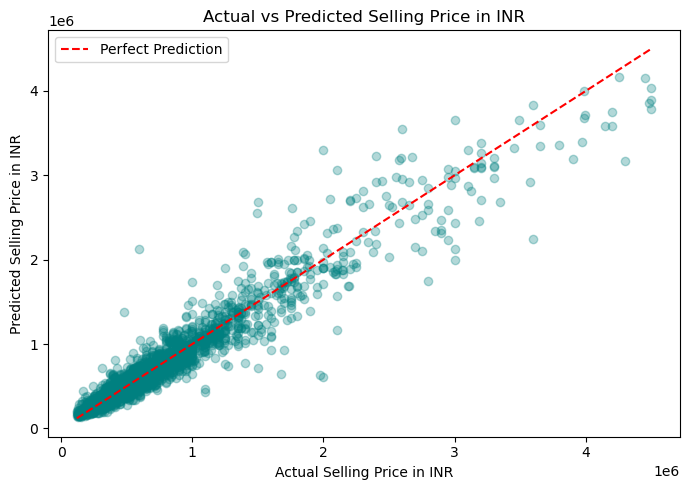

In [69]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='red', label='Perfect Prediction')
plt.xlabel('Actual Selling Price in INR')
plt.ylabel('Predicted Selling Price in INR')
plt.title('Actual vs Predicted Selling Price in INR')
plt.legend()
plt.tight_layout()
plt.savefig('plot6_actual_vs_predicted.png')
plt.show()

In [70]:
importances = model.feature_importances_
importances

array([0.0151594 , 0.15593589, 0.03624458, 0.00257019, 0.00220078,
       0.00358426, 0.02937115, 0.03186604, 0.71883173, 0.004236  ])

In [71]:
feat_names = X.columns.tolist()
feat_names

['brand',
 'vehicle_age',
 'km_driven',
 'seller_type',
 'fuel_type',
 'transmission_type',
 'mileage',
 'engine',
 'max_power',
 'seats']

In [72]:
sorted_idx = np.argsort(importances)[::-1]
sorted_idx

array([8, 1, 2, 7, 6, 0, 9, 5, 3, 4])

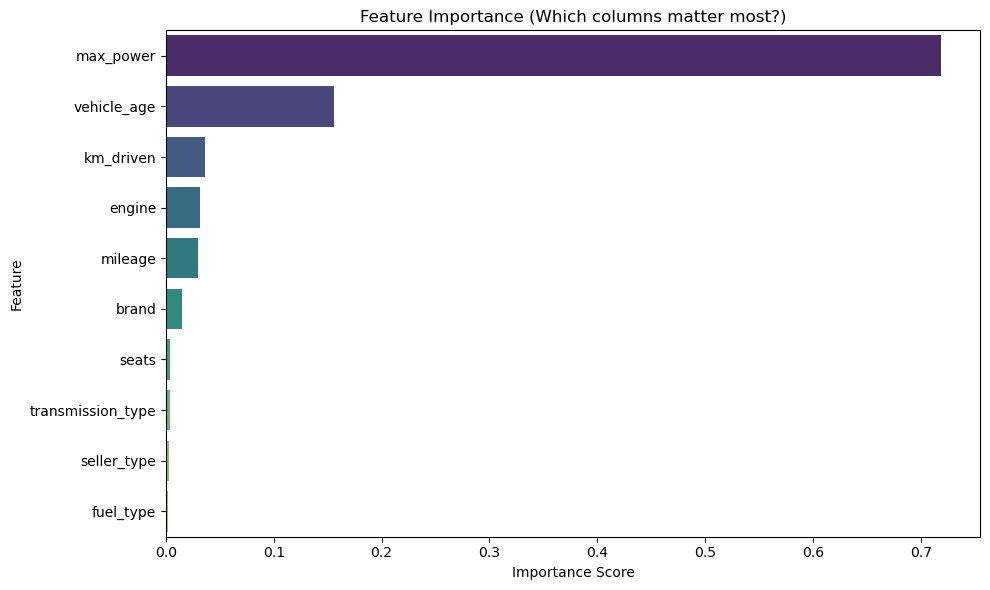

In [73]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_idx], y=np.array(feat_names)[sorted_idx], palette='viridis')
plt.title('Feature Importance (Which columns matter most?)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('plot7_feature_importance.png')
plt.show()

In [74]:
# Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator= RandomForestRegressor(random_state=42),
    param_grid= param_grid,
    cv=3,
    scoring='r2',
    n_jobs = -1,
    verbose= 1
)

print('Searching for best hyperparameters... (may take some time)')
grid_search.fit(X_train, y_train)
print('Search Complete')

Searching for best hyperparameters... (may take some time)
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Search Complete


In [75]:
print('Best Hyperparameters:')
print(grid_search.best_params_)

print(f'Best CV R2 score : {grid_search.best_score_:.4f}')

Best Hyperparameters:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Best CV R2 score : 0.9229


In [76]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print('Metrics for Tuned Random Forest Regression Model')
print(f'MAE : {mae_best}')
print(f'RMSE : {rmse_best}')
print(f'R2 Score : {r2_best}')

Metrics for Tuned Random Forest Regression Model
MAE : 90602.8209604762
RMSE : 157295.76624365154
R2 Score : 0.9262278278537696


In [77]:
joblib.dump(best_model, 'best_car_price_model.pkl')
print('\nSaved : best_car_price_model.pkl')


Saved : best_car_price_model.pkl


In [78]:
loaded_model = joblib.load('best_car_price_model.pkl')
print('Model loaded successfully')

Model loaded successfully


In [79]:
#  ['brand',
#  'vehicle_age',
#  'km_driven',
#  'seller_type',
#  'fuel_type',
#  'transmission_type',
#  'mileage',
#  'engine',
#  'max_power',
#  'seats']


In [80]:
new_car = pd.DataFrame({
    'brand' : [0],
    'vehicle_age' : [5],
    'km_driven' : [40000],
    'seller_type' : [0],
    'fuel_type' : [0],
    'transmission_type' : [1],
    'mileage' : [20],
    'engine' : [1197],
    'max_power' : [82],
    'seats' : [5]
})

In [81]:
predicted_price = loaded_model.predict(new_car)
print(f'Predicted Selling Price : {predicted_price[0]:.2f} INR')

Predicted Selling Price : 393815.24 INR
